# 01 - Sticker localization

Stage 1 of 3: given the full raw photo, find the sticker - predict its
axis-aligned bounding box (as `xmin, ymin, xmax, ymax`, normalized to
`[0, 1]` by canvas size). Trained against the ground-truth box derived from
`corners_xy` (see `src/geometry.corners_to_bbox`), which notebook 00 verified
visually.

Uses the same SKU-level split as every other stage (`data/raw/splits.json`)
so the real product catalog stays completely unseen everywhere, not just for
the OCR stage where it matters most - keeps `04_end_to_end_pipeline.ipynb`'s
eval unambiguous.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError("Could not locate the vision-ml project root from " + str(start))


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/lroland/Projects/github.com/distribution-center/vision-ml')

In [2]:
import contextlib
import json
import random

import matplotlib.pyplot as plt
import mlflow
import torch
from PIL import Image, ImageDraw
from torch import nn
from torch.utils.data import DataLoader

from src import datasets, geometry, models, settings, tracking

random.seed(0)
torch.manual_seed(0)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DEVICE


'mps'

## Load data

In [3]:
records = datasets.load_manifest(settings.RAW_DIR / "manifest.jsonl")
splits = json.loads((settings.RAW_DIR / "splits.json").read_text())


def _records_for(skus):
    sku_set = set(skus)
    return [r for r in records if r["sku"] in sku_set]


train_records = _records_for(splits["train_skus"])
val_records = _records_for(splits["val_skus"])
print(f"train: {len(train_records)} images   val: {len(val_records)} images")

BATCH_SIZE = 32
train_ds = datasets.LocalizationDataset(train_records, settings.RAW_DIR)
val_ds = datasets.LocalizationDataset(val_records, settings.RAW_DIR)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


train: 5440 images   val: 640 images


## Train

In [4]:
def batch_iou(pred: torch.Tensor, target: torch.Tensor) -> float:
    px0, py0, px1, py1 = pred.unbind(-1)
    tx0, ty0, tx1, ty1 = target.unbind(-1)
    ix0, iy0 = torch.maximum(px0, tx0), torch.maximum(py0, ty0)
    ix1, iy1 = torch.minimum(px1, tx1), torch.minimum(py1, ty1)
    intersection = (ix1 - ix0).clamp(min=0) * (iy1 - iy0).clamp(min=0)
    pred_area = (px1 - px0).clamp(min=0) * (py1 - py0).clamp(min=0)
    target_area = (tx1 - tx0).clamp(min=0) * (ty1 - ty0).clamp(min=0)
    union = (pred_area + target_area - intersection).clamp(min=1e-6)
    return (intersection / union).mean().item()


In [5]:
EPOCHS = 15
LR = 1e-3

model = models.LocalizerNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.SmoothL1Loss()

tracking.configure_tracking("localization")
run_ctx = mlflow.start_run(run_name="localizer") if tracking.is_enabled() else contextlib.nullcontext()

history = {"train_loss": [], "val_loss": [], "val_iou": []}
best_val_iou = -1.0
best_state_dict = None

with run_ctx:
    if tracking.is_enabled():
        mlflow.log_params({"epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR, "model": "LocalizerNet"})

    for epoch in range(EPOCHS):
        model.train()
        train_loss_total = 0.0
        for images, targets in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            preds = model(images)
            loss = loss_fn(preds, targets)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item() * images.size(0)
        train_loss = train_loss_total / len(train_ds)

        model.eval()
        val_loss_total = 0.0
        val_iou_total = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                preds = model(images)
                val_loss_total += loss_fn(preds, targets).item() * images.size(0)
                val_iou_total += batch_iou(preds, targets) * images.size(0)
        val_loss = val_loss_total / len(val_ds)
        val_iou = val_iou_total / len(val_ds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        is_best = val_iou > best_val_iou
        if is_best:
            best_val_iou = val_iou
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch + 1:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_iou={val_iou:.3f}{'  (best)' if is_best else ''}")

        if tracking.is_enabled():
            mlflow.log_metrics({"train_loss": train_loss, "val_loss": val_loss, "val_iou": val_iou}, step=epoch)

    # Save the best-val-IoU epoch's weights, not just whatever the last epoch happened to land
    # on - training is noisy enough (see the loss curve below) that the last epoch is often
    # worse than an earlier one.
    model.load_state_dict(best_state_dict)
    settings.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint_path = settings.MODELS_DIR / "localizer.pt"
    torch.save(model.state_dict(), checkpoint_path)
    if tracking.is_enabled():
        mlflow.log_metric("best_val_iou", best_val_iou)
        mlflow.log_artifact(str(checkpoint_path))

print(f"saved {checkpoint_path} (best val_iou={best_val_iou:.3f})")


epoch  1/15  train_loss=0.0127  val_loss=0.0046  val_iou=0.419  (best)


epoch  2/15  train_loss=0.0030  val_loss=0.0026  val_iou=0.460  (best)


epoch  3/15  train_loss=0.0019  val_loss=0.0021  val_iou=0.520  (best)


epoch  4/15  train_loss=0.0016  val_loss=0.0010  val_iou=0.627  (best)


epoch  5/15  train_loss=0.0012  val_loss=0.0014  val_iou=0.559


...

epoch 11/15  train_loss=0.0008  val_loss=0.0009  val_iou=0.677  (best)


epoch 12/15  train_loss=0.0007  val_loss=0.0010  val_iou=0.673


epoch 13/15  train_loss=0.0007  val_loss=0.0010  val_iou=0.674


epoch 14/15  train_loss=0.0006  val_loss=0.0017  val_iou=0.518


epoch 15/15  train_loss=0.0006  val_loss=0.0008  val_iou=0.700  (best)
saved /Users/lroland/Projects/github.com/distribution-center/vision-ml/data/models/localizer.pt (best val_iou=0.700)


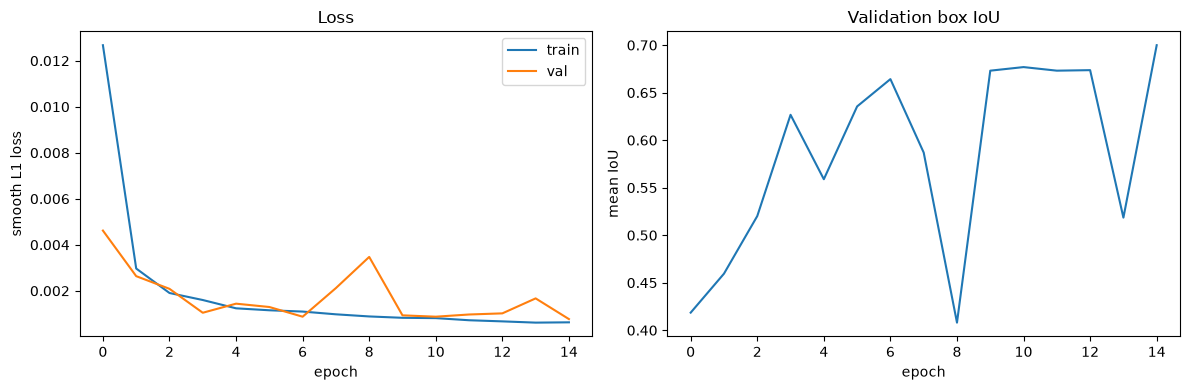

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_xlabel("epoch"); ax1.set_ylabel("smooth L1 loss"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(history["val_iou"])
ax2.set_xlabel("epoch"); ax2.set_ylabel("mean IoU"); ax2.set_title("Validation box IoU")
plt.tight_layout()
plt.show()


## Qualitative check: predicted vs. ground-truth box

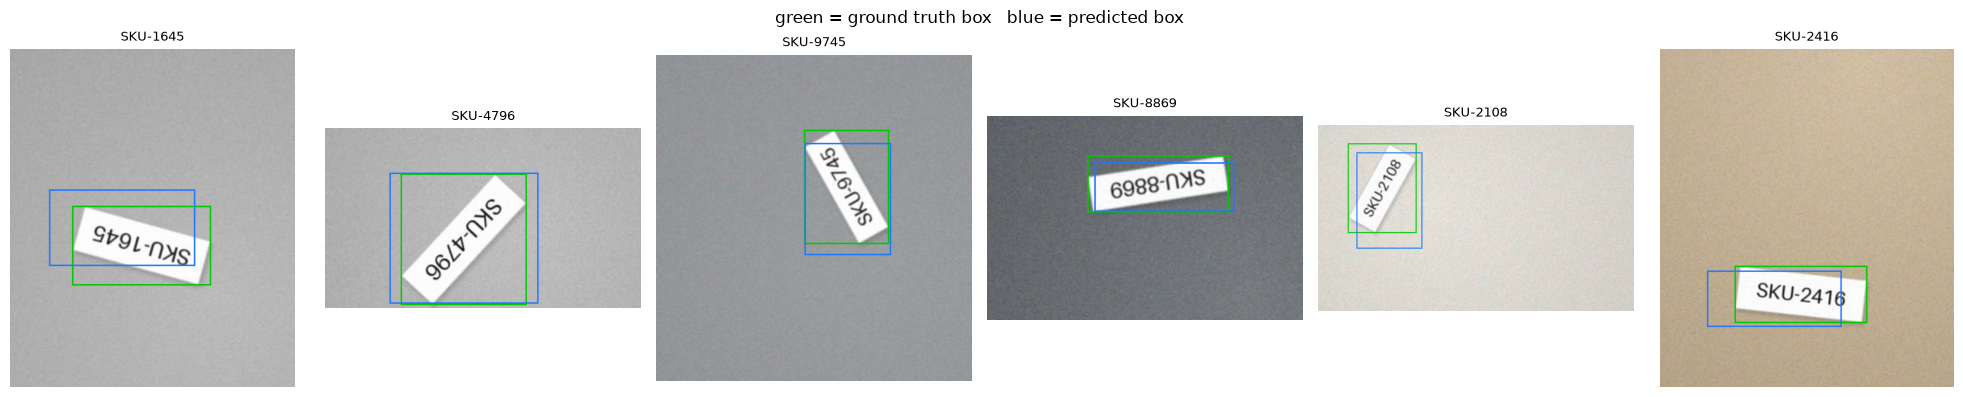

In [7]:
model.eval()
sample = random.sample(val_records, 6)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
with torch.no_grad():
    for ax, record in zip(axes, sample):
        image = Image.open(settings.RAW_DIR / record["image_path"]).convert("RGB")
        canvas_size = image.size
        resized = image.resize((models.LocalizerNet.INPUT_SIZE,) * 2, Image.BILINEAR)
        tensor = datasets.image_to_tensor(resized).unsqueeze(0).to(DEVICE)
        pred_norm = model(tensor)[0].cpu().tolist()
        pred_bbox = geometry.denormalize_bbox(pred_norm, canvas_size)
        gt_bbox = geometry.corners_to_bbox(record["corners_xy"])

        draw_img = image.copy()
        draw = ImageDraw.Draw(draw_img)
        draw.rectangle(gt_bbox, outline=(0, 200, 0), width=3)
        draw.rectangle(pred_bbox, outline=(30, 120, 255), width=3)
        ax.imshow(draw_img)
        ax.set_title(record["sku"], fontsize=9)
        ax.axis("off")

fig.suptitle("green = ground truth box   blue = predicted box")
plt.tight_layout()
plt.show()
